-----------------------------ASSIGNMENT1------------------------------------------

In [1]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
from torchvision import transforms
import kagglehub


In [2]:
from google.colab import drive
!mkdir drive
drive.mount('drive')

import pathlib

def get_filenames_of_path(path: pathlib.Path, ext: str = '*'):
    """Returns a list of files in a directory/path. Uses pathlib."""
    filenames = [str(file) for file in path.glob(ext) if file.is_file()]
    # delete duplicates
    filenames = [file for file in filenames if '(1)' not in file]
    return sorted(filenames)

root = pathlib.Path("drive/My Drive/data")

Mounted at drive


In [3]:
dataset_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
img_dir = os.path.join(dataset_path,"images")

In [4]:
class FashionDataset(Dataset):
    def __init__(self, csv_file, img_dir,column_class="articleTypeId", transform=None):
        """
        Args:
            csv_file (str): Path to the CSV file with labels.
            img_dir (str): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.df = pd.read_csv(csv_file)  # load CSV file
        self.img_dir = img_dir  # image folder path
        self.transform = transform  # image transformations
        self.targets = list(self.df[column_class].values)


    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, f"{self.df.loc[idx,'imageId']}.jpg")  # Get image filename
        image = Image.open(img_name).convert("RGB")  # Load image

        if self.transform:
            image = self.transform(image)  # Apply transformations

        return image, self.targets[idx]

dataset = FashionDataset(root/"train.csv",img_dir)
#dataset.df.head(30)

In [ ]:
# @title
#dataset.df.head()
#np.random.seed(42)
#random_indices = np.random.choice(len(dataset),3)
#
#for i in random_indices:
#    img, label = dataset[i]
#    plt.title(dataset.df.iloc[i]["articleTypeName"]+f" ({label.item()})")
#    plt.imshow(img)
#    plt.show()
#    print(img.size)

In [5]:
#Image size is 60x80. So lets tranform to 64x64
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])
train_dataset          = FashionDataset(root/"train.csv",img_dir,transform=transform)
main_test_dataset      = FashionDataset(root/"main_test.csv",img_dir,transform=transform)

main_support_dataset   = FashionDataset(root/"main_support.csv",img_dir,transform=transform)

new_support_dataset    = FashionDataset(root/"new_support.csv",img_dir,transform=transform)
new_test_dataset       = FashionDataset(root/"new_test.csv",img_dir,transform=transform)

merged_test_dataset    = FashionDataset(root/"merged_test.csv",img_dir,transform=transform) # merged corresponds to main+new
merged_support_dataset = FashionDataset(root/"merged_support.csv",img_dir,transform=transform)

main_test_dataset_cat =  FashionDataset(root/"main_test.csv",img_dir,column_class="categoryId",transform=transform)
main_support_dataset_cat =  FashionDataset(root/"main_support.csv",img_dir,column_class="categoryId",transform=transform)


label_id_to_label_name = {i: train_dataset.df[train_dataset.df["articleTypeId"]==i]["articleTypeName"].iloc[0] for i in range(39)}
from itertools import islice

for k, v in islice(label_id_to_label_name.items(), 3):
    print(k, ":", v)

#This is for TASK1: creating batches
from torch.utils.data import DataLoader
train_loader       = DataLoader(train_dataset,batch_size=36,shuffle=True)
test_loader        = DataLoader(main_test_dataset,batch_size=36,shuffle=True)
support_loader     = DataLoader(main_support_dataset,batch_size=36,shuffle=True)

new_support_loader = DataLoader(new_support_dataset,batch_size=36,shuffle=True)
new_test_loader = DataLoader(new_test_dataset,batch_size=36,shuffle=True)

merged_support_loader = DataLoader(merged_support_dataset,batch_size=36,shuffle=True)
merged_test_loader = DataLoader(merged_test_dataset,batch_size=36,shuffle=True)

main_support_cat_loader = DataLoader(main_support_dataset_cat,batch_size=36,shuffle=True)
main_test_cat_loader = DataLoader(main_test_dataset_cat,batch_size=36,shuffle=True)


0 : Tshirts
1 : Shirts
2 : Casual Shoes


USING CONV + FC ( from practical 2.3)

In [6]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionCnn(nn.Module):
    def __init__(self,num_classes=39):
        """CNN Builder."""
        super(FashionCnn, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), #32

            nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),#16

            nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) #512,8x8
        )

        self.classfier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(512*8*8,512), # fully connected layer
          nn.ReLU(),
          nn.Dropout(0.5),
          nn.Linear(512,39)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classfier(x)
        return x

    def get_embedding(self,x):
      return self.forward(x)

------------------------------------TASK1------------------------------------------------

TRAIN THE MODEL

In [ ]:
# @title
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device=torch.device('cpu')

model     = FashionCnn(num_classes=39).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = CrossEntropyLoss()


for epoch in tqdm(range(2)):
  model.train()
  for inputs,labels in train_loader:
    #inputs = inputs.unsqueeze(0)
    inputs = inputs.to(device)
    labels = torch.tensor(labels).to(device)
    outputs = model(inputs)
    loss = criterion(outputs,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

torch.save(model.state_dict(),root/"fashion_model.pth")

  0%|          | 0/10 [00:00<?, ?it/s]<ipython-input-8-c9b81004ab45>:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels).to(device)
100%|██████████| 10/10 [12:56<00:00, 77.64s/it]


ACCURACY

In [ ]:
# @title
from sklearn.metrics import balanced_accuracy_score,accuracy_score

def evaluate(model, dataloader):
  model.eval()
  y_true,y_pred = [],[]

  with torch.no_grad():
    for inputs,labels in test_loader:
      inputs  = inputs.to(device)
      outputs = model(inputs) # (batch_size,num_classes) = (36k/36,39)
      preds   = torch.argmax(outputs,dim=1).cpu().numpy() # finds the highest index, bring to cpu and convert to numpy
      y_true.extend(labels.numpy()) # convert label to numpy
      y_pred.extend(preds)

  acc = accuracy_score(y_true,y_pred)
  bal_acc = balanced_accuracy_score(y_true,y_pred)
  return acc,bal_acc

acc,bal_acc = evaluate(model,test_loader)
print(f"Accuarcy:{acc:.4f},Balanced Accuracy:{bal_acc:.4f}")




Accuarcy:0.8292,Balanced Accuracy:0.7620


In [ ]:
# @title
def evaluate(model, dataloader):
  model.eval()
  y_true,y_pred = [],[]

  with torch.no_grad():
    for inputs,labels in test_loader:
      inputs  = inputs.to(device)
      outputs = model(inputs) # (batch_size,num_classes) = (36k/36,39)
      preds   = torch.argmax(outputs,dim=1).cpu().numpy() # finds the highest index, bring to cpu and convert to numpy
      y_true.extend(labels.numpy()) # convert label to numpy
      y_pred.extend(preds)

  return y_true,y_pred

def compute_accuracy_and_balanced_accuracy(y_true,y_pred):
  total = len(y_true)
  total_correct = 0
  class_correct = {}
  class_total  = {}

  for yt,yp in zip(y_true,y_pred):
    if yt not in class_total: # If class never occurs
      class_total[yt] = 0
      class_correct[yt] = 0

    class_total[yt] +=1
    if yt==yp:
      total_correct+=1
      class_correct[yt] +=1

  acc = total_correct/total
  bal_acc = sum(class_correct[c]/class_total[c] for c in class_total)/len(class_total)
  return acc,bal_acc

y_true,y_pred = evaluate(model,test_loader)
acc,bal_acc = compute_accuracy_and_balanced_accuracy(y_true,y_pred)
print(f"Accuarcy:{acc:.4f},Balanced Accuracy:{bal_acc:.4f}")


Accuarcy:0.8292,Balanced Accuracy:0.7620


----------------------------------TASK 2 ----------------------------------------

PART 1

BALANCED BATCH SAMPLER

In [7]:
# @title
from torch.utils.data.sampler import BatchSampler
import numpy as np
class BalancedBatchSampler(BatchSampler):
    """
    Returns batches of size n_classes * n_samples
    """

    def __init__(self, labels, n_classes, n_samples):
        self.labels = labels
        self.labels_set = list(set(self.labels))
        self.label_to_indices = {label: np.where(  np.array(self.labels) == label)[0]
                                 for label in self.labels_set}
        for l in self.labels_set:
            np.random.shuffle(self.label_to_indices[l])
        self.used_label_indices_count = {label: 0 for label in self.labels_set}
        self.count = 0
        self.n_classes = n_classes
        self.n_samples = n_samples
        self.n_dataset = len(self.labels)
        self.batch_size = self.n_samples * self.n_classes

    def __iter__(self):
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []
            for class_ in classes:
                indices.extend(self.label_to_indices[class_][
                               self.used_label_indices_count[class_]:self.used_label_indices_count[
                                                                         class_] + self.n_samples])
                self.used_label_indices_count[class_] += self.n_samples
                if self.used_label_indices_count[class_] + self.n_samples > len(self.label_to_indices[class_]):
                    np.random.shuffle(self.label_to_indices[class_])
                    self.used_label_indices_count[class_] = 0
            yield indices
            self.count += self.n_classes * self.n_samples

    def __len__(self):
        return self.n_dataset // self.batch_size

GET TRAIN AND TEST BATCHES

In [8]:
# @title
import torch
import torch.nn as nn

train_sampler = BalancedBatchSampler(train_dataset.targets, n_classes=39, n_samples=10)
test_sampler = BalancedBatchSampler(main_test_dataset.targets, n_classes=39, n_samples=10)

train_loader_batches = torch.utils.data.DataLoader(train_dataset, batch_sampler=train_sampler)
test_loader_batches = torch.utils.data.DataLoader(main_test_dataset, batch_sampler=test_sampler)

for batch in train_loader_batches:
  inputs, labels = batch
  print(inputs.shape)
  #print(labels)
  break

torch.Size([390, 3, 64, 64])


RANDOM TRIPLET SELECTOR

In [9]:
# @title
from itertools import combinations

class RandomTripletSelector():
    """
    Select random negative  example for  each positive pair  to create triplets
    """

    def __init__(self):
        super(RandomTripletSelector, self).__init__()

    def get_triplets(self, embeddings, labels):
        labels = labels.cpu().data.numpy()
        triplets = []
        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(np.logical_not(label_mask))[0]
            anchor_positives = list(combinations(label_indices, 2))  # All anchor-positive pairs

            # random choose one negative example for each positive pair
            temp_triplets = [[anchor_positive[0], anchor_positive[1], np.random.choice(negative_indices)] for anchor_positive in anchor_positives]
            triplets += temp_triplets

        return torch.LongTensor(np.array(triplets))

COMPUTE TRIPLET LOSS

In [10]:
# @title
class TripletLoss(nn.Module):
    """
    Triplets loss
    Takes a batch of embeddings and corresponding labels.
    Triplets are generated using triplet_selector object that take embeddings and targets and return indices of
    triplets
    """

    def __init__(self, margin, triplet_selector):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.triplet_selector = triplet_selector

    def forward(self, embeddings, target):

        triplets = self.triplet_selector.get_triplets(embeddings, target)

        if embeddings.is_cuda:
            triplets = triplets.cuda()


        anchor_idx= triplets[:, 0]
        positive_idx= triplets[:, 1]
        negative_idx= triplets[:, 2]

        anchor = embeddings[anchor_idx]
        positive = embeddings[positive_idx]
        negative = embeddings[negative_idx]

        # Finish the triplet loss funtion
        # === ADD CODE HERE ===
        pos_dist = F.pairwise_distance(anchor,positive,p=2)
        neg_dist = F.pairwise_distance(anchor,negative,p=2)

        losses = F.relu(pos_dist-neg_dist+self.margin)

        return losses.mean()

TRAINING CLASS

In [11]:
# @title
import numpy as np
from tqdm import tqdm

class Trainer():
    def __init__(self,
                 model: torch.nn.Module,
                 device: torch.device,
                 criterion: torch.nn.Module,
                 optimizer: torch.optim.Optimizer,
                 training_DataLoader: torch.utils.data.Dataset,
                 validation_DataLoader: torch.utils.data.Dataset ,
                 epochs: int
                 ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs

    def run_trainer(self):

        for epoch in tqdm(range(self.epochs)):
            self.model.train()  # train mode
            train_losses=[]
            for batch in self.training_DataLoader:
                x,y=batch
                input, target = x.to(self.device), y.to(self.device)  # send to device (GPU or CPU)
                self.optimizer.zero_grad()  # zerograd the parameters
                out = self.model(input)  # one forward pass
                loss = self.criterion(out, target)  # calculate loss

                loss_value = loss.item()
                train_losses.append(loss_value)

                loss.backward()  # one backward pass
                self.optimizer.step()  # update the parameters

            self.model.eval()  # evaluation mode
            valid_losses = []  # accumulate the losses here

            for batch in self.validation_DataLoader:

                x,y=batch
                input, target = x.to(self.device), y.to(self.device)  # send to device (GPU or CPU)

                with torch.no_grad():
                    out = self.model(input)   # one forward pass
                    loss = self.criterion(out, target) # calculate loss
                    loss_value = loss.item()
                    valid_losses.append(loss_value)


            # print the results
            print(
                f'EPOCH: {epoch+1:0>{len(str(self.epochs))}}/{self.epochs}',
                end=' '
            )
            print(f'LOSS: {np.mean(train_losses):.4f}',end=' ')
            print(f'VAL-LOSS: {np.mean(valid_losses):.4f}',end='\n')
#torch.save(model.state_dict(),root/"fashion_model.pth")

TRAINING THE MODEL

In [12]:
# @title
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device=torch.device('cpu')

model     = FashionCnn(num_classes=39).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
margin=1
criterion = TripletLoss(margin,RandomTripletSelector())

trainer = Trainer(model=model,
                  optimizer=optimizer,
                  criterion=criterion,
                  device=device,
                  training_DataLoader=train_loader_batches,
                  validation_DataLoader =test_loader_batches,
                  epochs=10)
trainer.run_trainer()

 10%|█         | 1/10 [02:36<23:28, 156.46s/it]

EPOCH: 01/10 LOSS: 0.2723 VAL-LOSS: 0.1601


 20%|██        | 2/10 [04:00<15:09, 113.66s/it]

EPOCH: 02/10 LOSS: 0.1701 VAL-LOSS: 0.1189


 30%|███       | 3/10 [05:08<10:50, 92.98s/it] 

...

EPOCH: 08/10 LOSS: 0.0891 VAL-LOSS: 0.0733


 90%|█████████ | 9/10 [10:53<01:00, 60.37s/it]

EPOCH: 09/10 LOSS: 0.0832 VAL-LOSS: 0.0711


100%|██████████| 10/10 [11:47<00:00, 70.75s/it]

EPOCH: 10/10 LOSS: 0.0785 VAL-LOSS: 0.0690


PART 2: USING SUPER SET

In [86]:
def extract_embeddings(data,model):
  all_images=[]
  with torch.no_grad():
    model.eval()
    embeddings = np.zeros((len(data.dataset),39))
    labels = np.zeros(len(data.dataset))
    k=0

    cuda = torch.cuda.is_available()
    for images, cLass in data:
      if cuda:
        images = images.cuda()
      #print(len(images))
      embeddings[k:k+len(images)] = model.get_embedding(images).data.cpu().numpy()
      labels[k:k+len(images)]     = cLass.numpy()
      k += len(images)
      all_images.append(images.cpu())
    all_images = torch.cat(all_images)
  return embeddings,labels,all_images

#Concatenate


main_class_train_embeddings,main_class_train_labels,train_images = extract_embeddings(train_loader,model)
main_class_support_embeddings,main_class_support_labels,support_images = extract_embeddings(support_loader,model)
main_class_test_embeddings,main_class_test_labels,test_images = extract_embeddings(test_loader,model)

#new_support_embeddings,new_support_labels = extract_embeddings(new_support_loader,model)
#new_test_embeddings,new_test_labels = extract_embeddings(new_test_loader,model)

#merged_support_embeddings,merged_support_labels = extract_embeddings(merged_support_loader,model)
#merged_test_embeddings,merged_test_labels = extract_embeddings(merged_test_loader,model)

#main_support_cat_embeddings,main_support_cat_labels = extract_embeddings(main_support_cat_loader,model)
#main_test_cat_embeddings,main_test_cat_labels = extract_embeddings(main_test_cat_loader,model)

CLASSIFY IMAGES OF TEST USING SUPPORT SET : CHANGE ACCURACY FUNC HERE

In [ ]:
# @title
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import accuracy_score

#Scenario 2: Main class support , Main classes Test
s2_distances = euclidean_distances(main_class_test_embeddings,main_class_support_embeddings)
s2_closest_ind = np.argmin(s2_distances,axis=1)
s2_predicted_class = main_class_support_labels[s2_closest_ind]

#Scenario 3: New classes support, New Classes test
s3_distances = euclidean_distances(new_test_embeddings,new_support_embeddings)
s3_closest_ind = np.argmin(s3_distances,axis=1)
s3_predicted_class = new_support_labels[s3_closest_ind]

#Scenario 4: Merged classes support, Merged classes Test
s4_distances = euclidean_distances(merged_test_embeddings,merged_support_embeddings)
s4_closest_ind = np.argmin(s4_distances,axis=1)
s4_predicted_class = merged_support_labels[s4_closest_ind]


s2_accuracy = accuracy_score(main_class_test_labels,s2_predicted_class)
s3_accuracy = accuracy_score(new_test_labels,s3_predicted_class)
s4_accuracy = accuracy_score(merged_test_labels,s4_predicted_class)
print(f"Accuracy of Test Database using support set:{s2_accuracy:.4f}")
print(f"Accuracy of New test Database using new set:{s3_accuracy:.4f}")
print(f"Accuracy of Merged test Database using merge set:{s4_accuracy:.4f}")

Accuracy of Test Database using support set:0.6745
Accuracy of New test Database using new set:0.7006
Accuracy of Merged test Database using merge set:0.6087


PLOT THE EMBEDDINGS

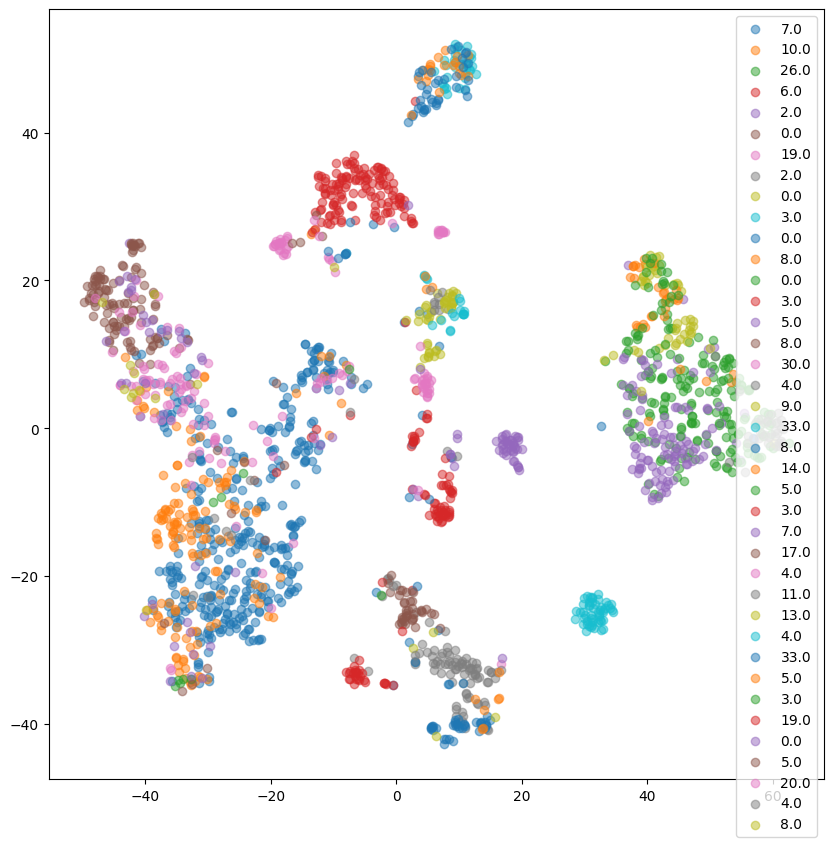

In [ ]:
# @title
from sklearn.manifold import TSNE

def plot_tsne_embeddings(embeddings,cLass,xlim=None,ylim=None):
  embeddings = embeddings[:3000]
  cLass = cLass[:3000]

  tsne =TSNE(n_components=2)
  embeddings = tsne.fit_transform(embeddings)

  plt.figure(figsize=(10,10))
  for i in range(39):
    inds = np.where(cLass==i)[0]
    plt.scatter(embeddings[inds,0],embeddings[inds,1],alpha=0.5)
    if xlim:
        plt.xlim(xlim[0], xlim[1])
    if ylim:
        plt.ylim(ylim[0], ylim[1])
    plt.legend(cLass)

plot_tsne_embeddings(main_class_test_embeddings,main_class_test_labels)




---------------------------------TASK3----------------------------------------

RECOMMENDATION SYSTEM

In [38]:
# @title
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import accuracy_score


#main_support_cat_embeddings,main_support_cat_labels
#main_test_cat_embeddings,main_test_cat_labels

#rec_distances = euclidean_distances(main_test_cat_embeddings,main_class_support_embeddings)
rec_distances = euclidean_distances(merged_test_embeddings,merged_support_embeddings)
print(rec_distances.shape)
sorted_index = np.argsort(rec_distances,axis=1)
sorted_distances = np.sort(rec_distances,axis=1)

top3_index = sorted_index[:,:3]
top3_rec = sorted_distances[:,:3]
top3_confidence = np.exp(-1*top3_rec)

threshold=0.5
chosen = top3_confidence>threshold
final_rec = np.where(chosen,top3_index,-1)
final_confidence = np.where(chosen,top3_confidence,0)

#print(final_rec.shape)

(3657, 3655)


In [ ]:
# @title
num_queries = final_rec.shape[0]

for i in range(num_queries):
    print(f"Query {i+1}:")
    for j in range(3):
        idx = final_rec[i, j]
        conf = final_confidence[i, j]
        if idx != -1:
            print(f"  Recommendation {j+1}: Support Index = {idx}, Confidence = {conf:.2f}")
        else:
            print(f"  Recommendation {j+1}: Filtered (below threshold)")
    print("-" * 40)

Query 1:
  Recommendation 1: Filtered (below threshold)
  Recommendation 2: Filtered (below threshold)
  Recommendation 3: Filtered (below threshold)
----------------------------------------
Query 2:
  Recommendation 1: Filtered (below threshold)
  Recommendation 2: Filtered (below threshold)
  Recommendation 3: Filtered (below threshold)
----------------------------------------
Query 3:
  Recommendation 1: Filtered (below threshold)
  Recommendation 2: Filtered (below threshold)
  Recommendation 3: Filtered (below threshold)
----------------------------------------
Query 4:
  Recommendation 1: Filtered (below threshold)
  Recommendation 2: Filtered (below threshold)
  Recommendation 3: Filtered (below threshold)
----------------------------------------
Query 5:
  Recommendation 1: Filtered (below threshold)
  Recommendation 2: Filtered (below threshold)
  Recommendation 3: Filtered (below threshold)
----------------------------------------
Query 6:
  Recommendation 1: Filtered (below 

Computing Error rate and Coverage

In [ ]:
# @title
total_rec_incorrect =0
total_rec=0
#for i in range(len(main_test_cat_labels)):
for i in range(len(merged_test_labels)):
  #query_label = main_test_cat_labels[i]
  query_label = merged_test_labels[i]
  rec_indices = final_rec[i]
  valid_indices = rec_indices[rec_indices!=-1] # so cool

  if(len(valid_indices)!=0):
    total_rec +=1

  #recommended_label = main_support_cat_labels[valid_indices]
  recommended_label = merged_support_labels[valid_indices]
  if((len(valid_indices)==0) or (not np.any(recommended_label==query_label))):
    total_rec_incorrect +=1

#error_rate = sum(len(row) for row in incorrect)/sum(len(row) for row in valid_indices)
#error_rate = total_rec_incorrect/len(main_test_cat_labels)
#coverage   = total_rec/len(main_test_cat_labels)
error_rate = total_rec_incorrect/len(merged_test_labels)
coverage = total_rec/len(merged_test_labels)
print(error_rate)
print(coverage)

0.8055783429040196
0.21821164889253486


PLOT

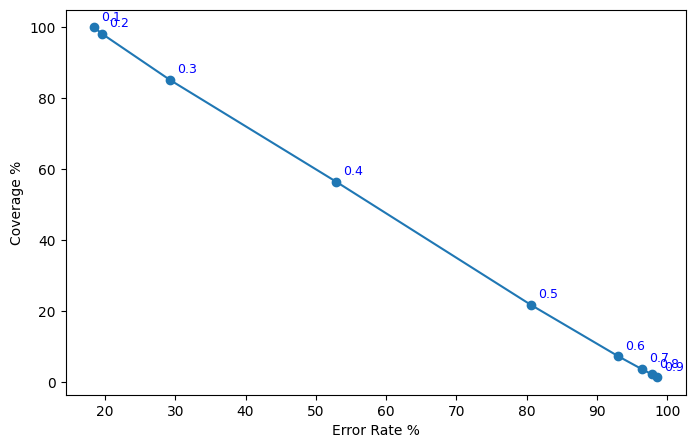

In [ ]:
# @title
threshold = np.arange(0.1,1,0.1)
error_rates = []
coverages = []

for T in threshold:
  chosen = top3_confidence>T
  final_rec = np.where(chosen,top3_index,-1)
  final_confidence = np.where(chosen,top3_confidence,0)
  total_rec_incorrect =0
  total_rec=0
  #for i in range(len(main_test_cat_labels)):
    #query_label = main_test_cat_labels[i]
  for i in range(len(merged_test_labels)):
    query_label = merged_test_labels[i]
    rec_indices = final_rec[i]
    valid_indices = rec_indices[rec_indices!=-1] # so cool

    if(len(valid_indices)!=0):
      total_rec +=1

    #recommended_label = main_support_cat_labels[valid_indices]
    recommended_label = merged_support_labels[valid_indices]
    if((len(valid_indices)==0) or (not np.any(recommended_label==query_label))):
      total_rec_incorrect +=1

  #error_rate = total_rec_incorrect/len(main_test_cat_labels)
  #coverage   = total_rec/len(main_test_cat_labels)
  error_rate = total_rec_incorrect/len(merged_test_labels)
  coverage = total_rec/len(merged_test_labels)
  error_rates.append(error_rate*100)
  coverages.append(coverage*100)

plt.figure(figsize=(8,5))
plt.plot(error_rates,coverages,marker='o')
plt.xlabel("Error Rate %")
plt.ylabel("Coverage %")

# Annotate each point with its threshold value
for i, T in enumerate(threshold):
    plt.annotate(f'{T:.1f}',
                 (error_rates[i], coverages[i]),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left',
                 fontsize=9,
                 color='blue')


plt.show()



TASK 4 : BEYOND LABELS

STEP1: Dimensionality Reduction

In [27]:
# @title
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
pca=PCA(n_components=2) # required is 2D
print(main_class_train_embeddings.shape)

(35934, 39)


In [43]:
# @title
label_range=range(10)
train_mask = np.isin(main_class_train_labels,label_range)
test_mask = np.isin(main_class_test_labels,label_range)
support_mask = np.isin(main_class_support_labels,label_range)

#Step1
plot_train_embeddings = main_class_train_embeddings[train_mask]
plot_train_labels = main_class_train_labels[train_mask]

plot_test_embeddings  = main_class_test_embeddings[test_mask]
plot_test_labels = main_class_test_labels[test_mask]

#Step2
cm_support_embeddings = main_class_support_embeddings[support_mask]
cm_support_labels = main_class_support_labels[support_mask]

#Apply PCA
pca_train_embeddings = scaler.fit_transform(plot_train_embeddings)
pca_train_embeddings = pca.fit_transform(plot_train_embeddings)
pca_test_embeddings = pca.fit_transform(plot_test_embeddings)
print(pca_train_embeddings.shape)

(22911, 2)


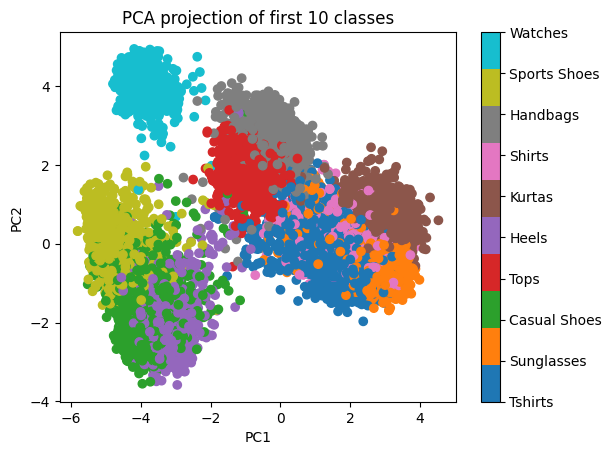

{'Tshirts', 'Sunglasses', 'Casual Shoes', 'Tops', 'Heels', 'Kurtas', 'Shirts', 'Handbags', 'Sports Shoes', 'Watches'}


In [50]:
# @title
#PLOT
first_10_labels = set([label_id_to_label_name[i] for i in plot_train_labels])
scatter = plt.scatter(pca_train_embeddings[:, 0], pca_train_embeddings[:, 1], c=plot_train_labels, cmap='tab10')
plt.title("PCA projection of first 10 classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
#plt.xlim(-40,60)
#plt.ylim(-40,60)
#plt.colorbar(label="Class Label")
#plt.text(first_10_labels)

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(10))
cbar.set_ticklabels(first_10_labels)
#cbar.set_label(first_10_labels)
plt.show()
print(first_10_labels)


In [21]:
print(plot_train_labels)

[8. 0. 9. ... 2. 4. 8.]


STEP 2: Verifying our assumption with a confusion matrix

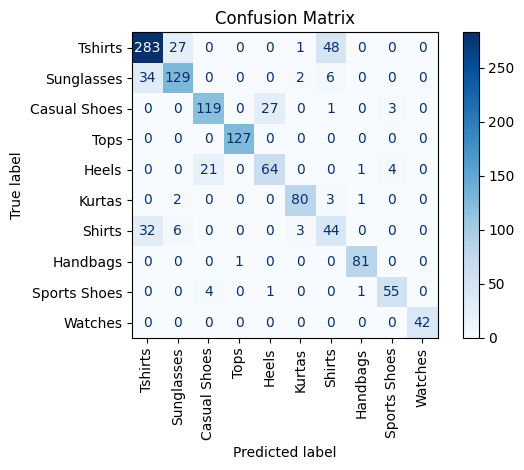

In [49]:
# @title
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

#Find the closest support embedding for the test embedding and get true_lable and predicted label.

dist = euclidean_distances(plot_test_embeddings,cm_support_embeddings)
nearest_indices = np.argmin(dist,axis=1)
predicted_labels = cm_support_labels[nearest_indices]
cm = confusion_matrix(predicted_labels,plot_test_labels)
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=first_10_labels)

display.plot(cmap='Blues',xticks_rotation=90)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

STEP 3: A closer look at shirts vs T shirts

Centroid Computation

In [67]:
print(label_id_to_label_name)

{0: 'Tshirts', 1: 'Shirts', 2: 'Casual Shoes', 3: 'Watches', 4: 'Sports Shoes', 5: 'Kurtas', 6: 'Tops', 7: 'Handbags', 8: 'Heels', 9: 'Sunglasses', 10: 'Wallets', 11: 'Flip Flops', 12: 'Sandals', 13: 'Briefs', 14: 'Belts', 15: 'Backpacks', 16: 'Socks', 17: 'Formal Shoes', 18: 'Perfume and Body Mist', 19: 'Jeans', 20: 'Shorts', 21: 'Trousers', 22: 'Flats', 23: 'Bra', 24: 'Dresses', 25: 'Sarees', 26: 'Earrings', 27: 'Deodorant', 28: 'Nail Polish', 29: 'Lipstick', 30: 'Track Pants', 31: 'Clutches', 32: 'Sweatshirts', 33: 'Caps', 34: 'Sweaters', 35: 'Jackets', 36: 'Ties', 37: 'Innerwear Vests', 38: 'Kurtis'}


In [99]:
#Training
tshirt_support_indices = np.isin(main_class_support_labels,0)
tshirt_support_embeddings = main_class_support_embeddings[tshirt_support_indices]
tshirt_support_labels = main_class_support_labels[tshirt_support_indices]
tshirt_support_images = support_images[tshirt_support_indices]
print(tshirt_support_embeddings.shape)

shirt_support_indices = np.isin(main_class_support_labels,1)
shirt_support_embeddings = main_class_support_embeddings[shirt_support_indices]
shirt_support_labels = main_class_support_labels[shirt_support_indices]
shirt_support_images = support_images[shirt_support_indices]
print(shirt_support_embeddings.shape)

#Test
tshirt_test_indices = np.isin(main_class_test_labels,0)
tshirt_test_embeddings = main_class_test_embeddings[tshirt_test_indices]
tshirt_test_labels = main_class_test_labels[tshirt_test_indices]
tshirt_test_images = test_images[tshirt_test_indices]
print(tshirt_test_embeddings.shape)

shirt_test_indices = np.isin(main_class_test_labels,1)
shirt_test_embeddings = main_class_test_embeddings[shirt_test_indices]
shirt_test_labels = main_class_test_labels[shirt_test_indices]
shirt_test_images = test_images[shirt_test_indices]
print(shirt_test_embeddings.shape)

(381, 39)
(145, 39)
(349, 39)
(164, 39)


Centroids

In [91]:
tshirt_train_centroid = tshirt_support_embeddings.mean(axis=0)
shirt_train_centroid = shirt_support_embeddings.mean(axis=0)

tshirt_test_centroid = tshirt_test_embeddings.mean(axis=0)
shirt_test_centroid = shirt_test_embeddings.mean(axis=0)

Finding the closest image to this centroid

(39,)
(381, 39)


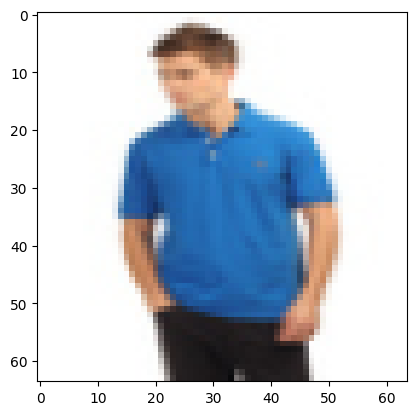

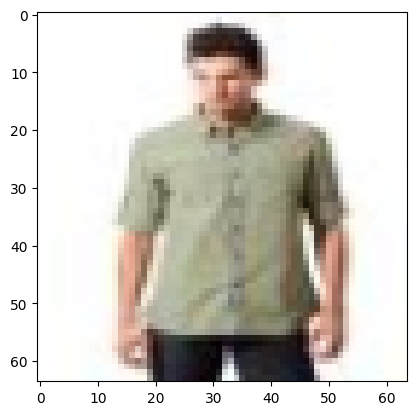

In [100]:
#Training dataset for Tshirt and shirt
print(tshirt_test_centroid.shape)
print(tshirt_support_embeddings.shape)
closest_tshirt_train_indx = np.argmin(euclidean_distances(tshirt_train_centroid.reshape(1,-1),tshirt_support_embeddings))
Tshirt_image = tshirt_support_images[closest_tshirt_train_indx]
plt.imshow(Tshirt_image.permute(1,2,0).numpy())
plt.show()

closest_shirt_train_indx = np.argmin(euclidean_distances(shirt_train_centroid.reshape(1,-1),shirt_support_embeddings))
shirt_image = shirt_support_images[closest_shirt_train_indx]
plt.imshow(shirt_image.permute(1,2,0).numpy())
plt.show()
